# Audience Segmentation with K-Means Clustering

Dataset: https://www.kaggle.com/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews

Goal: Cluster anime titles into audience/content segments using metadata only (unsupervised).

Important: `score`, `rank`, and `ranked` are excluded from clustering features to avoid leakage.
Actual `score` is used only for post-hoc cluster comparison.

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_utils import load_raw_tables
from src.preprocessing import prepare_kmeans_features
from src.clustering import train_cluster_and_save

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## 2. Load and Describe Dataset

In [2]:
base_dir = Path.cwd()
data = load_raw_tables(start_dir=base_dir)

animes = data["animes"]
profiles = data["profiles"]
reviews = data["reviews"]

print("animes shape:", animes.shape)
print("profiles shape:", profiles.shape)
print("reviews shape:", reviews.shape)
print("animes path:", data["paths"]["animes"])
print("profiles path:", data["paths"]["profiles"])
print("reviews path:", data["paths"]["reviews"])

animes shape: (19311, 12)
profiles shape: (81727, 5)
reviews shape: (192112, 7)
animes path: C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\animes.csv
profiles path: C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\profiles.csv
reviews path: C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\data\reviews.csv


In [3]:
print("animes columns:")
display(pd.DataFrame({"column": animes.columns}))

print("profiles columns:")
display(pd.DataFrame({"column": profiles.columns}))

print("reviews columns:")
display(pd.DataFrame({"column": reviews.columns}))

animes columns:


,column
0,uid
1,title
2,synopsis
3,genre
4,aired
5,episodes
6,members
7,popularity
8,ranked
9,score


profiles columns:


,column
0,profile
1,gender
2,birthday
3,favorites_anime
4,link


reviews columns:


,column
0,uid
1,profile
2,anime_uid
3,text
4,score
5,scores
6,link


## 3. Preprocessing and Feature Engineering

In [4]:
X, analysis_df, meta = prepare_kmeans_features(animes, profiles, reviews)

print("Feature matrix shape:", X.shape)
print("Numeric features:", len(meta["numeric_cols"]))
print("Categorical features:", len(meta["categorical_cols"]))
print("Dropped high-cardinality categoricals:", meta["dropped_high_cardinality_categoricals"])

display(X.head(3))

Feature matrix shape: (19311, 10)
Numeric features: 10
Categorical features: 0
Dropped high-cardinality categoricals: ['title', 'genre']


,episodes,members,popularity,aired_year,genre_count,title_len,synopsis_len,favorites_count,review_count,review_text_len_mean
0,25.0,489888,141,2015.0,5.0,23.0,1041.0,513.0,104.0,3875.288462
1,22.0,995473,28,2014.0,5.0,23.0,838.0,2971.0,40.0,6055.750000
2,13.0,581663,98,2017.0,5.0,13.0,1214.0,1571.0,610.0,3563.455738


## 4. Train K-Means with Dimensionality Reduction and Save Artifacts

In [5]:
artifacts_dir = base_dir / "artifacts"
output = train_cluster_and_save(X=X, analysis_df=analysis_df, artifacts_dir=artifacts_dir)

print("Best K:", output["best_k"])
print("SVD components:", output["n_svd"])
print("Model path:", output["model_path"])

display(output["k_eval"])

Best K: 2
SVD components: 9
Model path: C:\Users\yasho\Downloads\Entertainment-Rating-Prediction-ML\kmeans_clustering\artifacts\kmeans_pipeline.joblib


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,124725.726195,0.676421,3379.815650,0.825714
1,3,102800.336658,0.255872,3697.282668,1.377942
2,4,92940.757334,0.182609,3272.287248,1.472637
3,5,84214.803833,0.185949,3108.390031,1.262677
4,6,76343.628908,0.193369,3061.339498,1.227244
5,7,69485.893117,0.202985,3056.671917,1.192615
6,8,64975.971177,0.192541,2954.769167,1.261801
7,9,61205.101005,0.192911,2863.433814,1.128888
8,10,57950.067792,0.177007,2784.440888,1.223178


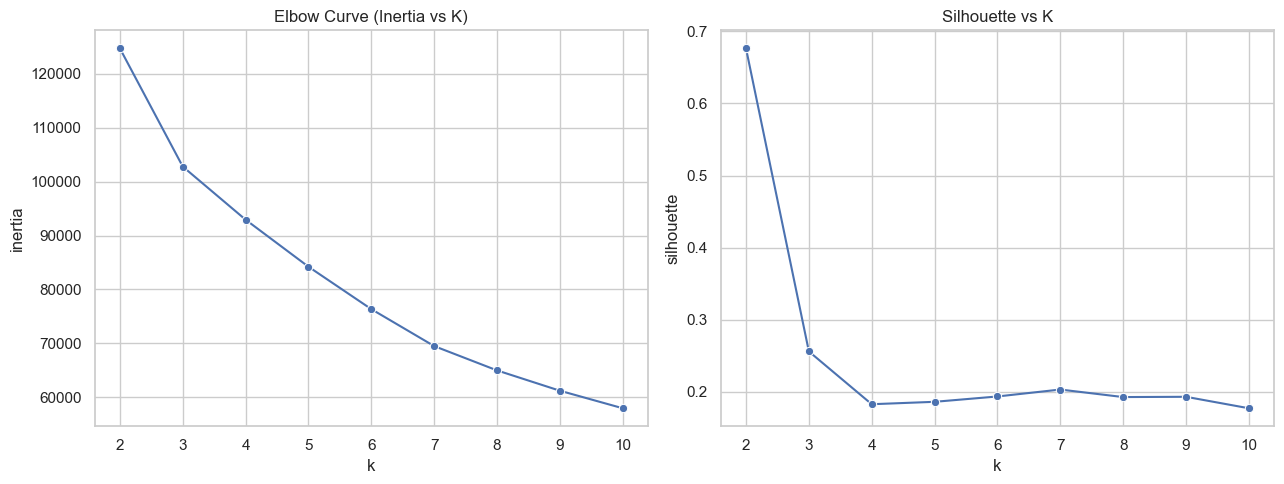

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=output["k_eval"], x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Curve (Inertia vs K)")

sns.lineplot(data=output["k_eval"], x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette vs K")

plt.tight_layout()
plt.show()

## 5. Cluster Interpretation

In [7]:
display(output["cluster_profile"])

display(output["cluster_meanings"])

,cluster,cluster_size,score_mean,score_median,score_std,members_mean,members_median,popularity_mean,popularity_median
0,0,18913,6.397153,6.39,0.981212,22037.135092,2237.0,7879.611326,7699.0
1,1,398,8.230503,8.25,0.419166,637706.723618,547934.0,175.540201,112.5


,cluster,cluster_label,reason
0,0,Long-tail / Lower Engagement,Lower members and broader long-tail catalog
1,1,Mainstream / High Engagement,High members and concentrated popularity


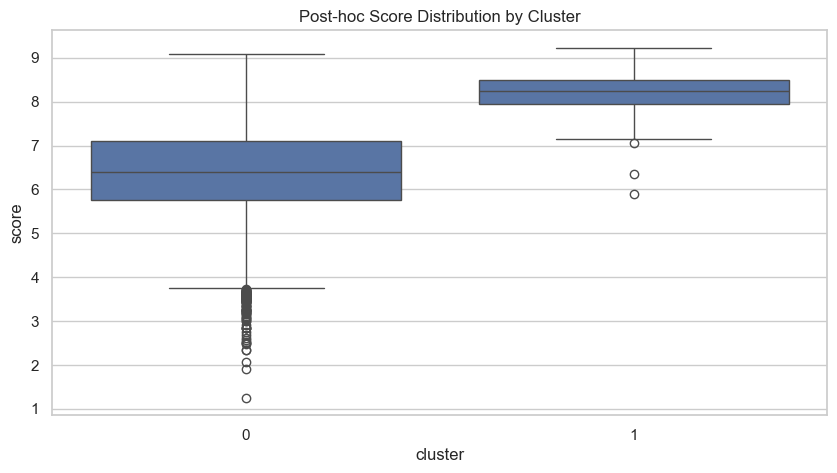

In [8]:
cluster_assignments = output["assignments"].copy()

if "score" in cluster_assignments.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=cluster_assignments, x="cluster", y="score")
    plt.title("Post-hoc Score Distribution by Cluster")
    plt.show()
else:
    print("Score column not available for post-hoc comparison.")

In [9]:
# Show representative titles to justify cluster naming.

display(output["cluster_examples"])

,cluster,cluster_label,title,members,score,popularity
0,0,Long-tail / Lower Engagement,Shingeki no Kyojin Season 3,608172,8.49,93
1,0,Long-tail / Lower Engagement,Tonari no Kaibutsu-kun,591503,7.65,95
2,0,Long-tail / Lower Engagement,Shokugeki no Souma: Ni no Sara,562262,8.38,107
3,0,Long-tail / Lower Engagement,Fairy Tail (2014),537817,7.97,115
4,0,Long-tail / Lower Engagement,Tonari no Totoro,528128,8.42,120
5,1,Mainstream / High Engagement,Death Note,1871043,8.65,1
6,1,Mainstream / High Engagement,Shingeki no Kyojin,1754979,8.47,2
7,1,Mainstream / High Engagement,Sword Art Online,1657823,7.49,3
8,1,Mainstream / High Engagement,Fullmetal Alchemist: Brotherhood,1615084,9.23,4
9,1,Mainstream / High Engagement,One Punch Man,1475219,8.68,5


## 6. Test Custom Inputs (Manual)

In [10]:
# Use an existing row template and modify values to test custom scenarios.
custom_input = X.head(1).copy()

# Example edits (optional):
if "episodes" in custom_input.columns:
    custom_input["episodes"] = 12
if "members" in custom_input.columns:
    custom_input["members"] = 150000

pipeline = None
import joblib
pipeline = joblib.load(artifacts_dir / "kmeans_pipeline.joblib")
pred_cluster = int(pipeline.predict(custom_input)[0])
print("Predicted cluster for custom input:", pred_cluster)

cluster_meanings = output.get("cluster_meanings", pd.DataFrame())
if not cluster_meanings.empty:
    label_row = cluster_meanings.loc[cluster_meanings["cluster"] == pred_cluster, "cluster_label"]
    if not label_row.empty:
        print("Predicted segment:", label_row.iloc[0])

display(custom_input)

Predicted cluster for custom input: 0
Predicted segment: Long-tail / Lower Engagement


,episodes,members,popularity,aired_year,genre_count,title_len,synopsis_len,favorites_count,review_count,review_text_len_mean
0,12,150000,141,2015.0,5.0,23.0,1041.0,513.0,104.0,3875.288462


## 7. Saved Files



After running this notebook, check `kmeans_clustering/artifacts/` for:

- kmeans_pipeline.joblib

- k_evaluation.csv

- cluster_assignments.csv

- cluster_profile.csv

- cluster_meanings.csv

- cluster_examples.csv

- metadata.json